In [42]:
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import trustworthiness
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import math
import os

In [20]:
os.environ["LOKY_MAX_CPU_COUNT"] = '14'
os.environ["OMP_NUM_THREADS"] = "1"

In [21]:
bronze = pd.read_csv("processed_csvs/bronze.csv")
champion = pd.read_csv("processed_csvs/champion.csv")
diamond = pd.read_csv("processed_csvs/diamond.csv")
gold = pd.read_csv("processed_csvs/gold.csv")
grand = pd.read_csv("processed_csvs/grand.csv")
platinum = pd.read_csv("processed_csvs/platinum.csv")
silver = pd.read_csv("processed_csvs/silver.csv")
supersonic = pd.read_csv("processed_csvs/supersonic.csv")

ranks = {"Bronze": bronze, "Champion": champion, "Diamond": diamond, "Gold": gold, "Grandchampion": grand, 
         "Platinum": platinum, "Silver": silver, "Supersonic": supersonic}

low = pd.concat([bronze, silver, gold], ignore_index=True)
intermediate = pd.concat([platinum, diamond, champion], ignore_index=True)
high = pd.concat([grand, supersonic], ignore_index=True)

rank_levels = {'Low': low, 'Intermediate': intermediate, 'High': high}

In [22]:
ranks['Bronze'].columns

Index(['color', 'player name', 'platform', 'player id', 'car id', 'car name',
       'game duration', 'score', 'goals', 'assists', 'saves', 'shots',
       'shots conceded', 'goals conceded',
       'goals conceded while last defender', 'shooting percentage', 'bpm',
       'avg boost amount', 'amount collected', 'amount collected big pads',
       'amount collected small pads', 'count collected big pads',
       'count collected small pads', 'amount stolen', 'amount stolen big pads',
       'amount stolen small pads', 'count stolen big pads',
       'count stolen small pads', '0 boost time', '100 boost time',
       'amount used while supersonic', 'amount overfill total',
       'amount overfill stolen', 'avg speed', 'total distance',
       'time slow speed', 'percentage slow speed', 'time boost speed',
       'percentage boost speed', 'time supersonic speed',
       'percentage supersonic speed', 'time on ground', 'percentage on ground',
       'time low in air', 'percentage low in a

In [32]:
for rank, df in rank_levels.items():
    rank_levels[rank] = df.dropna()

rank_sne = {}

for rank, df in rank_levels.items():
    temp = df.drop(columns=[
    'color','player name','platform','player id','car id','car name','rank'])
    rank_sne[rank] = temp

for rank, df in rank_sne.items():
    check = df.var().sort_values()
    for j in check.index:
        if check[j] == 0:
            print(j)

for rank, df in rank_sne.items():
    print(df.isna().sum().sort_values())

game duration                 0
score                         0
goals                         0
assists                       0
saves                         0
                             ..
percentage neutral third      0
time offensive third          0
percentage offensive third    0
demos inflicted               0
demos taken                   0
Length: 66, dtype: int64
game duration                 0
score                         0
goals                         0
assists                       0
saves                         0
                             ..
percentage neutral third      0
time offensive third          0
percentage offensive third    0
demos inflicted               0
demos taken                   0
Length: 66, dtype: int64
game duration                 0
score                         0
goals                         0
assists                       0
saves                         0
                             ..
percentage neutral third      0
time offensive third  

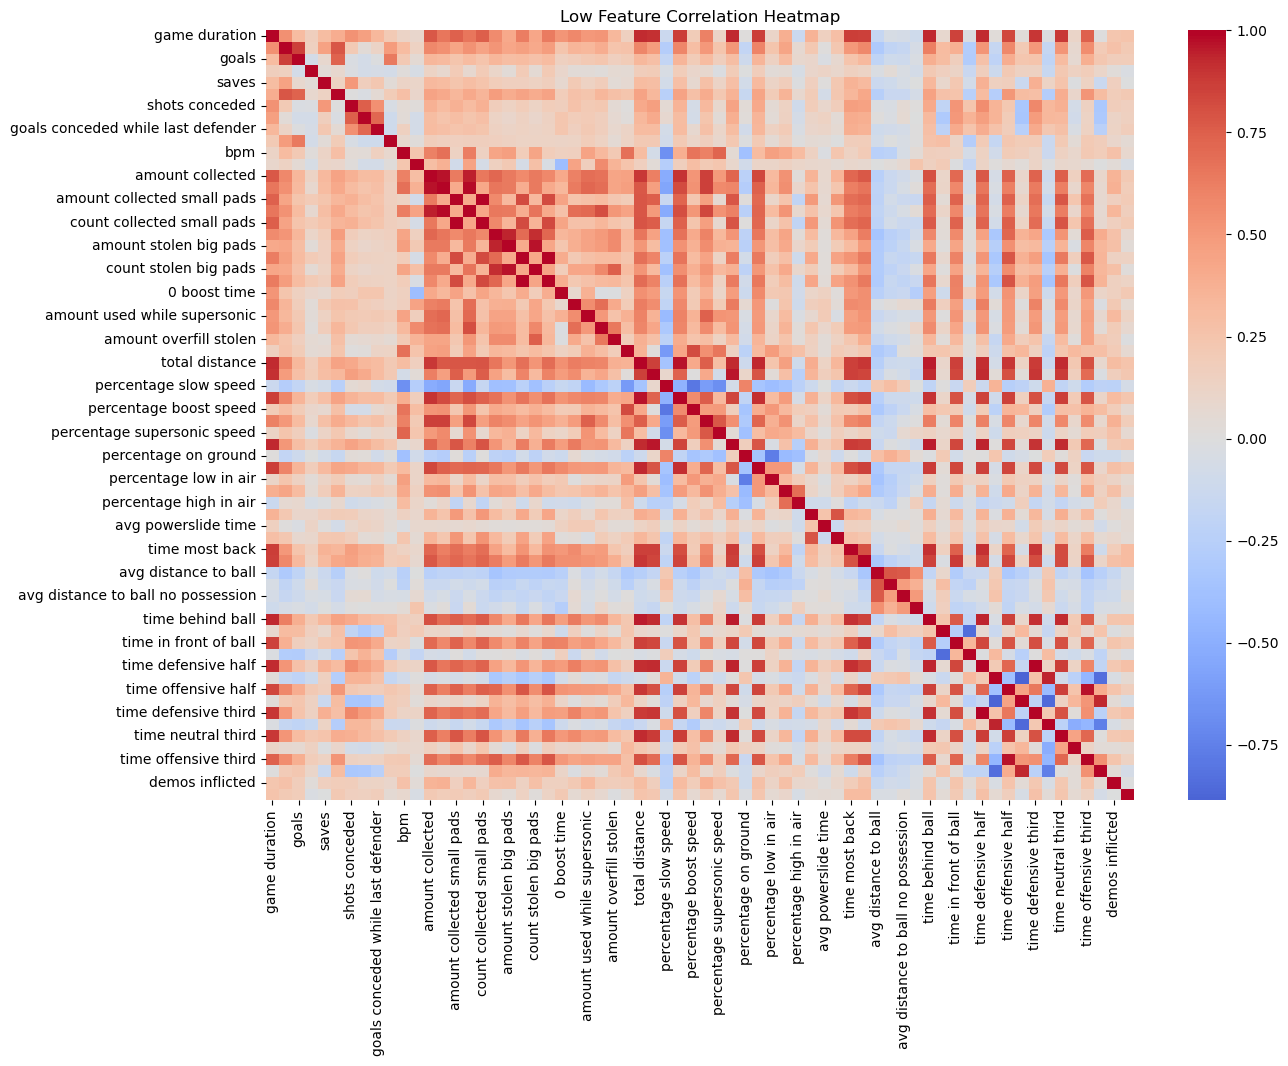

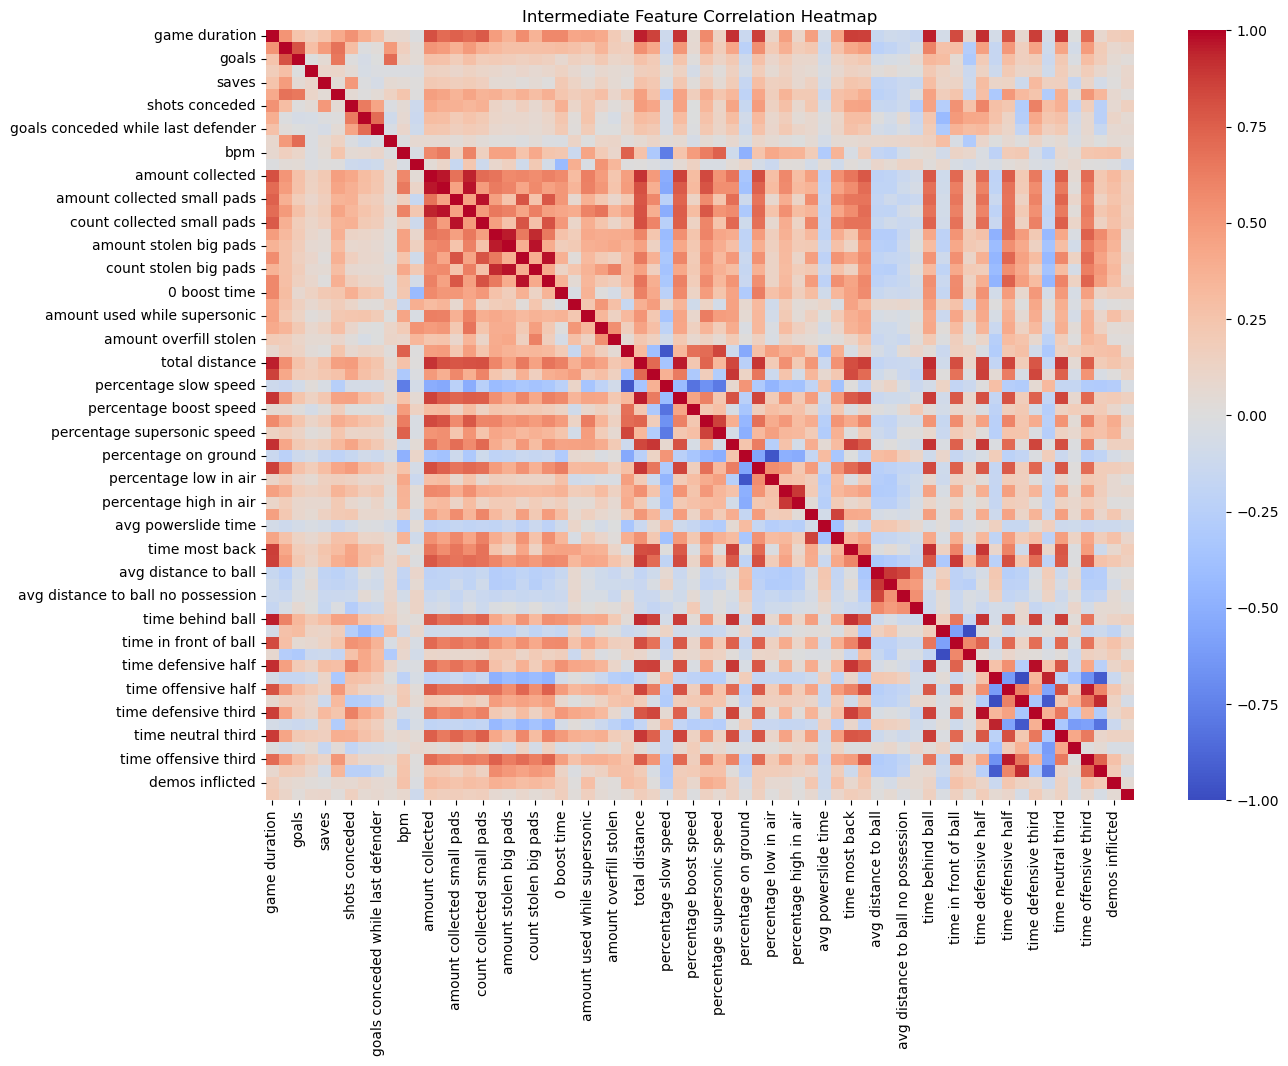

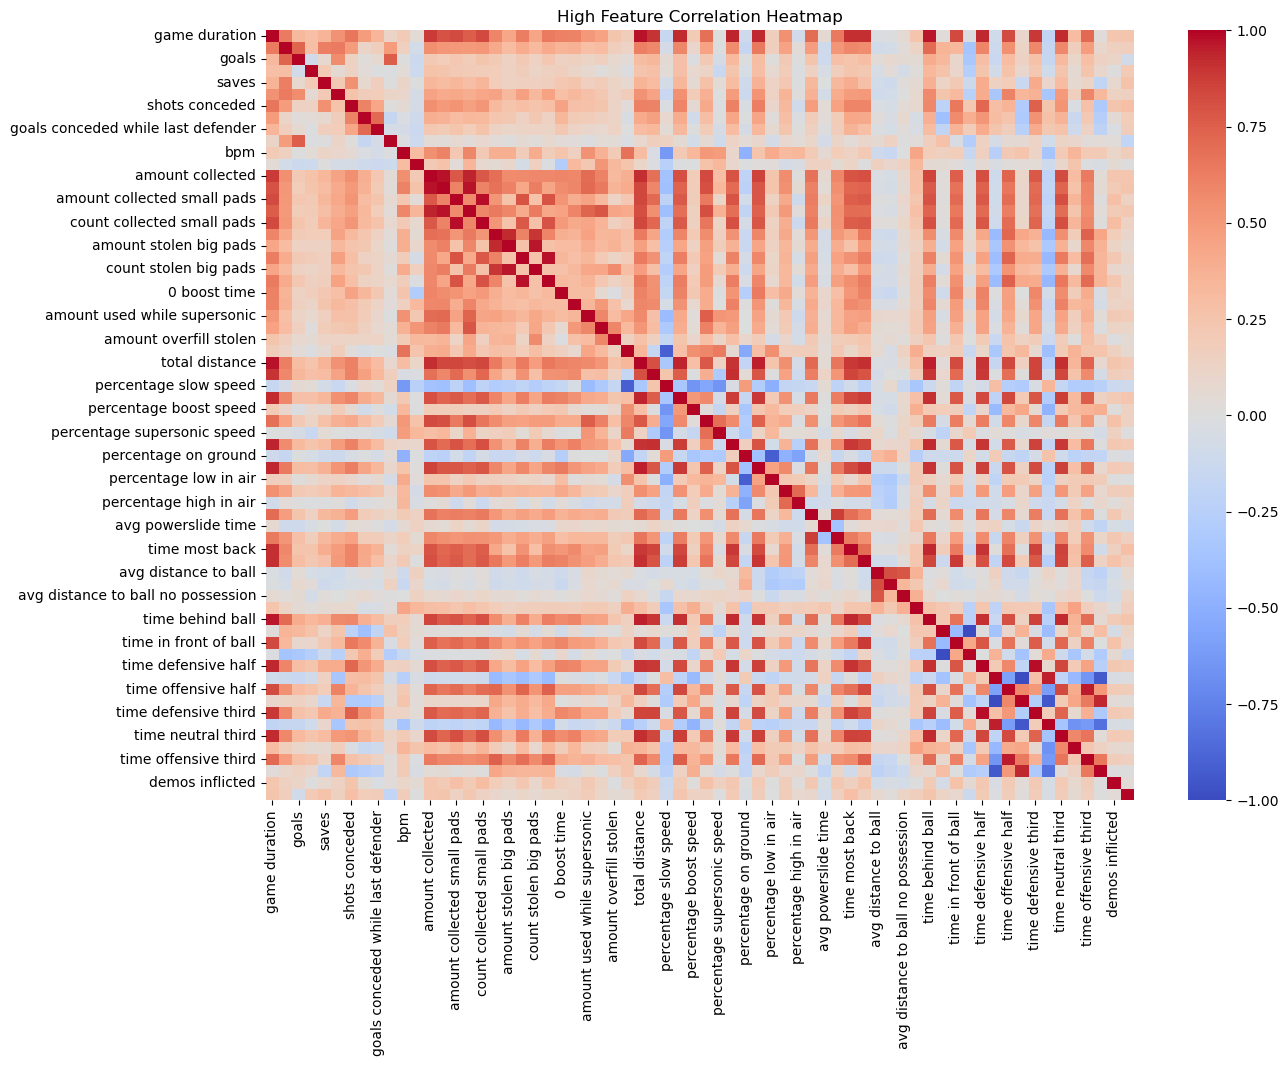

In [33]:
for rank, df in rank_sne.items():
    corr = df.select_dtypes(include='number').corr()
    
    plt.figure(figsize=(14,10))
    sns.heatmap(corr, cmap="coolwarm", center=0)
    plt.title(f"{rank} Feature Correlation Heatmap")
    plt.show()

1 components: 0.3554
2 components: 0.4637
3 components: 0.5390
4 components: 0.5959
5 components: 0.6343
6 components: 0.6706
7 components: 0.7022
8 components: 0.7293
9 components: 0.7508
10 components: 0.7711
11 components: 0.7892
12 components: 0.8062
13 components: 0.8230
14 components: 0.8393
15 components: 0.8540
16 components: 0.8673
17 components: 0.8795
18 components: 0.8913
19 components: 0.9026
20 components: 0.9129
21 components: 0.9228
22 components: 0.9312
23 components: 0.9389
24 components: 0.9459
25 components: 0.9524
26 components: 0.9580
27 components: 0.9631
28 components: 0.9673
29 components: 0.9711
30 components: 0.9744
31 components: 0.9775
32 components: 0.9804
33 components: 0.9829
34 components: 0.9848
35 components: 0.9867
36 components: 0.9884
37 components: 0.9900
38 components: 0.9917
39 components: 0.9930
40 components: 0.9943
41 components: 0.9953
42 components: 0.9961
43 components: 0.9968
44 components: 0.9974
45 components: 0.9979
46 components: 0.99

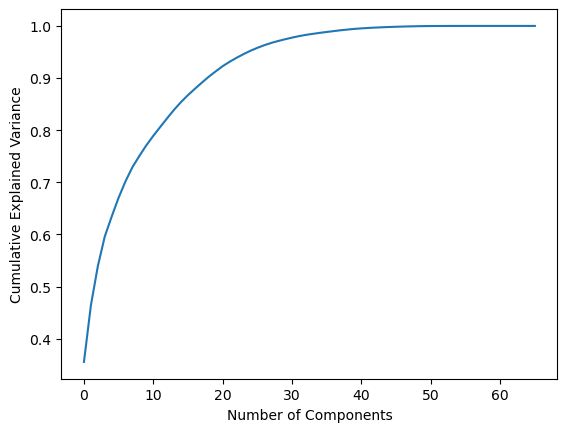

In [34]:
scaler = StandardScaler()
rank_scaled = scaler.fit_transform(rank_sne['Low'])

pca = PCA()
pca.fit(rank_scaled)

plt.plot(pca.explained_variance_ratio_.cumsum())
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
cum_var = np.cumsum(pca.explained_variance_ratio_)
for i, val in enumerate(np.cumsum(pca.explained_variance_ratio_), start=1):
    print(f"{i} components: {val:.4f}")

In [35]:
tsne_data = {}

for rank, df in rank_sne.items():
    scaler = StandardScaler()
    rank_scaled = scaler.fit_transform(df)

    rank_pca = PCA(n_components=18).fit_transform(rank_scaled)
    rank_tsne = TSNE(n_components=2, random_state=42).fit_transform(rank_pca)

    tsne_data[rank] = [rank_pca,rank_tsne]

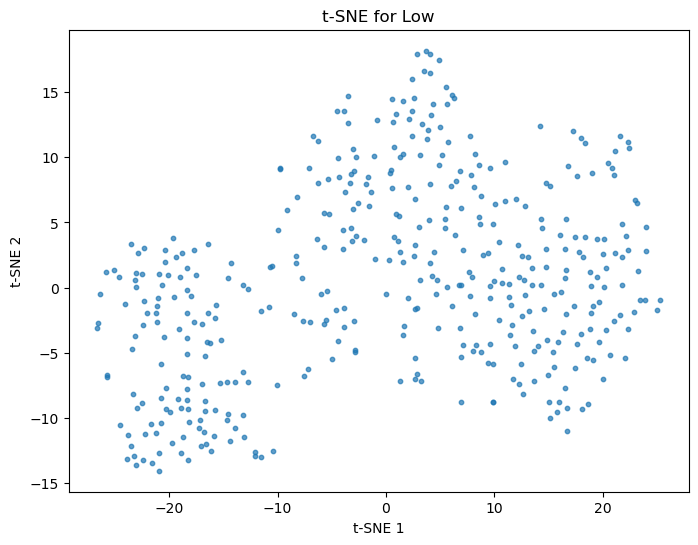

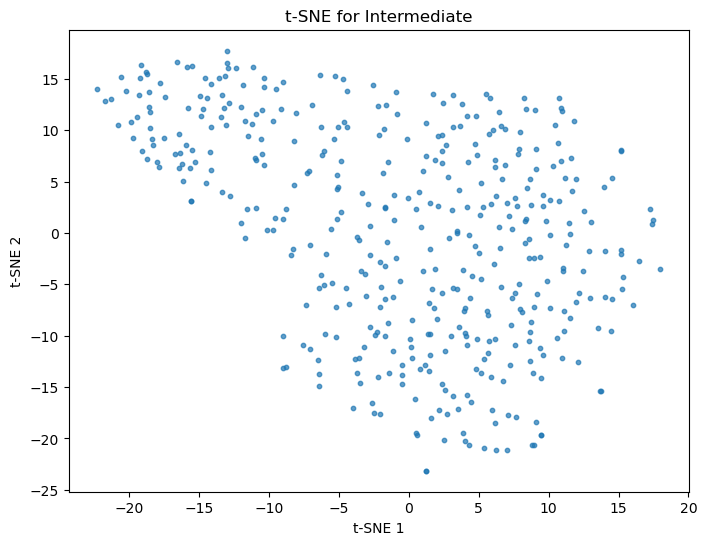

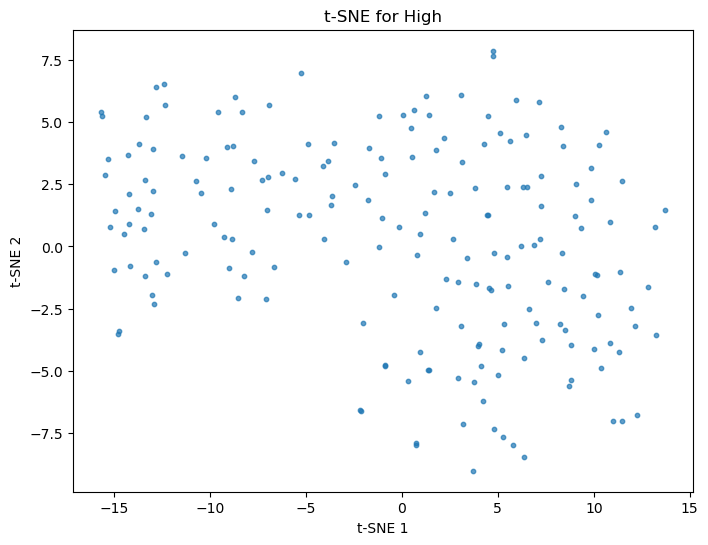

In [36]:
for rank, coords in tsne_data.items():
    plt.figure(figsize=(8, 6))
    plt.scatter(coords[1][:, 0], coords[1][:, 1], s=10, alpha=0.7)
    plt.title(f"t-SNE for {rank}")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.show()

In [37]:
for rank, coords, in tsne_data.items():
    
    score = trustworthiness(coords[0], coords[1], n_neighbors=5)
    print(f'{rank} trustworthiness: {score}')

Low trustworthiness: 0.9567464170134073
Intermediate trustworthiness: 0.9504327871492411
High trustworthiness: 0.9306329257246377


In [38]:
for rank, coords, in tsne_data.items():
    labels = KMeans(n_clusters=5).fit_predict(coords[1])
    sil = silhouette_score(coords[1], labels)
    print(f'{rank} silhoutte score: {sil}')

Low silhoutte score: 0.3815423250198364
Intermediate silhoutte score: 0.3980081379413605
High silhoutte score: 0.4174240529537201


C:\Users\rcand\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\rcand\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\rcand\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [44]:
tsne_data_raw = {}

for rank, df in rank_sne.items():
    scaler = StandardScaler()
    rank_scaled = scaler.fit_transform(df)

    rank_tsne = TSNE(n_components=2, random_state=42, perplexity=10).fit_transform(rank_scaled)

    tsne_data_raw[rank] = rank_tsne

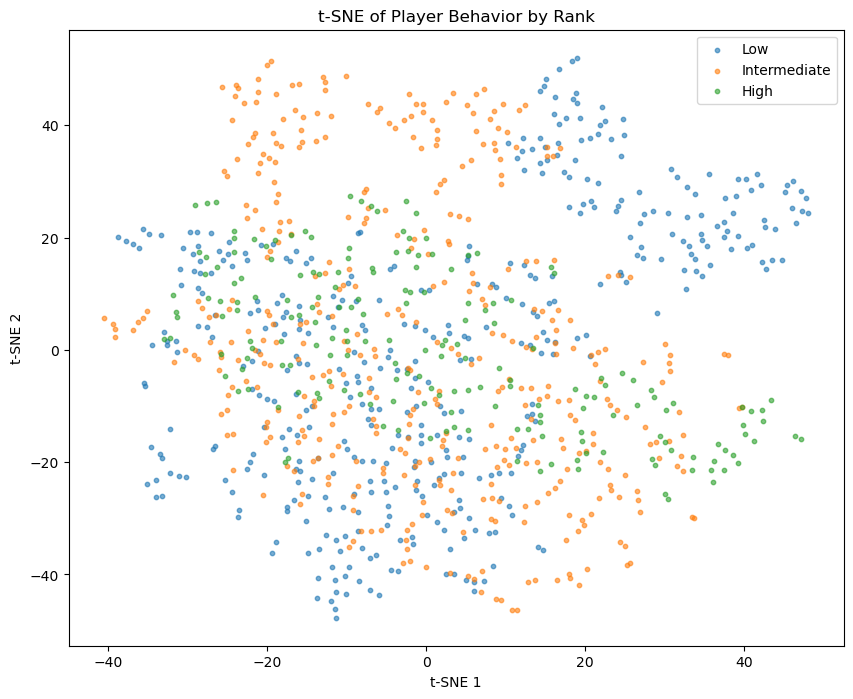

In [45]:
plt.figure(figsize=(10,8))

for rank, coords in tsne_data_raw.items():
    plt.scatter(coords[:,0], coords[:,1], label=rank, s=10, alpha=0.6)

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE of Player Behavior by Rank")
plt.legend()
plt.show()

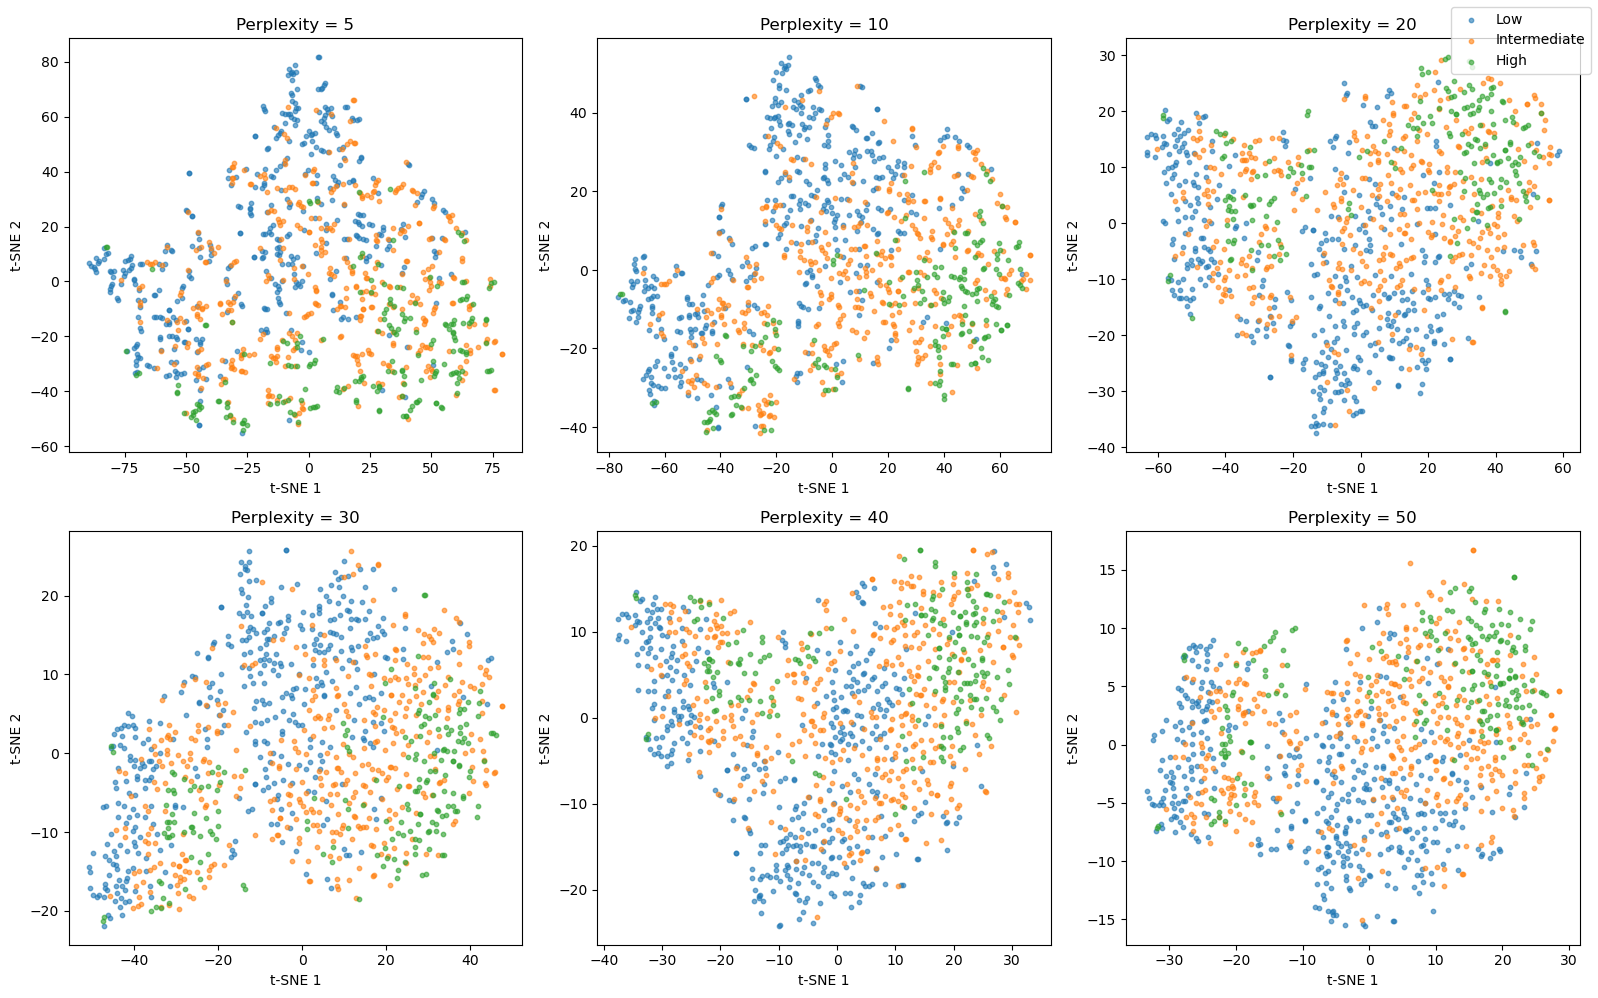

In [43]:
combined_list = []

for rank, df in rank_sne.items():
    temp = df.copy()
    temp["rank_label"] = rank
    combined_list.append(temp)

combined_df = pd.concat(combined_list, ignore_index=True)

# Separate labels from features
labels = combined_df["rank_label"]
X = combined_df.drop(columns=["rank_label"])

# Keep numeric columns only, just in case
X = X.select_dtypes(include="number")

# Scale once
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Perplexity values
perplexities = [5, 10, 20, 30, 40, 50]

# Grid layout
cols = 3
rows = math.ceil(len(perplexities) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows))
axes = axes.flatten()

for ax, p in zip(axes, perplexities):
    coords = TSNE(
        n_components=2,
        perplexity=p,
        random_state=42
    ).fit_transform(X_scaled)

    for rank in labels.unique():
        mask = labels == rank
        ax.scatter(
            coords[mask, 0],
            coords[mask, 1],
            label=rank,
            s=10,
            alpha=0.6
        )

    ax.set_title(f"Perplexity = {p}")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")

# Turn off empty axes if needed
for ax in axes[len(perplexities):]:
    ax.axis("off")

# Use one shared legend
handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(handles, legend_labels, loc="upper right")

plt.tight_layout()
plt.show()